# House Price Prediction Using Machine Learning

### XYlofy AI Internship – Week 1 Project

**Submitted By:** Anamika V P

In [6]:
from google.colab import files
uploaded = files.upload()


Saving Housing.csv to Housing.csv


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [8]:
df = pd.read_csv("Housing.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [9]:
df.head(10)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [10]:
print(df.shape)

(545, 13)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [12]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [13]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [14]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df[col] = df[col].map({
        'yes':1,
        'no':0
    })

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [15]:
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [16]:
X = df.drop('price', axis=1)

y = df['price']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 13)
Testing Data: (109, 13)


In [18]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

print("Linear Regression Completed")

Linear Regression Completed


In [19]:
lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print("MAE =", lr_mae)
print("RMSE =", lr_rmse)
print("R2 =", lr_r2)

MAE = 970043.4039201637
RMSE = 1324506.9600914384
R2 = 0.6529242642153185


In [20]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

print("Random Forest Completed")

Random Forest Completed


In [21]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("MAE =", rf_mae)
print("RMSE =", rf_rmse)
print("R2 =", rf_r2)

MAE = 1022560.0527522935
RMSE = 1401496.8425384816
R2 = 0.6114024924156645


In [22]:
comparison = pd.DataFrame({
    'Model':['Linear Regression',
             'Random Forest'],
    'MAE':[lr_mae,
           rf_mae],
    'RMSE':[lr_rmse,
            rf_rmse],
    'R2 Score':[lr_r2,
                rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


In [23]:
import os

os.makedirs(
    "charts",
    exist_ok=True
)

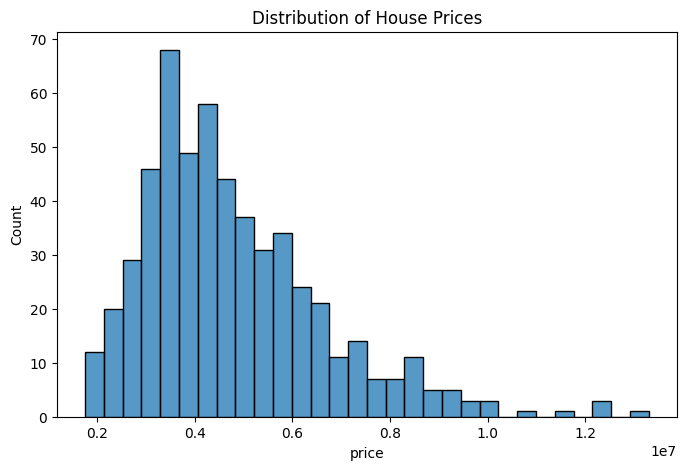

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['price'],
    bins=30
)

plt.title(
    "Distribution of House Prices"
)

plt.savefig(
    "charts/price_distribution.png"
)

plt.show()

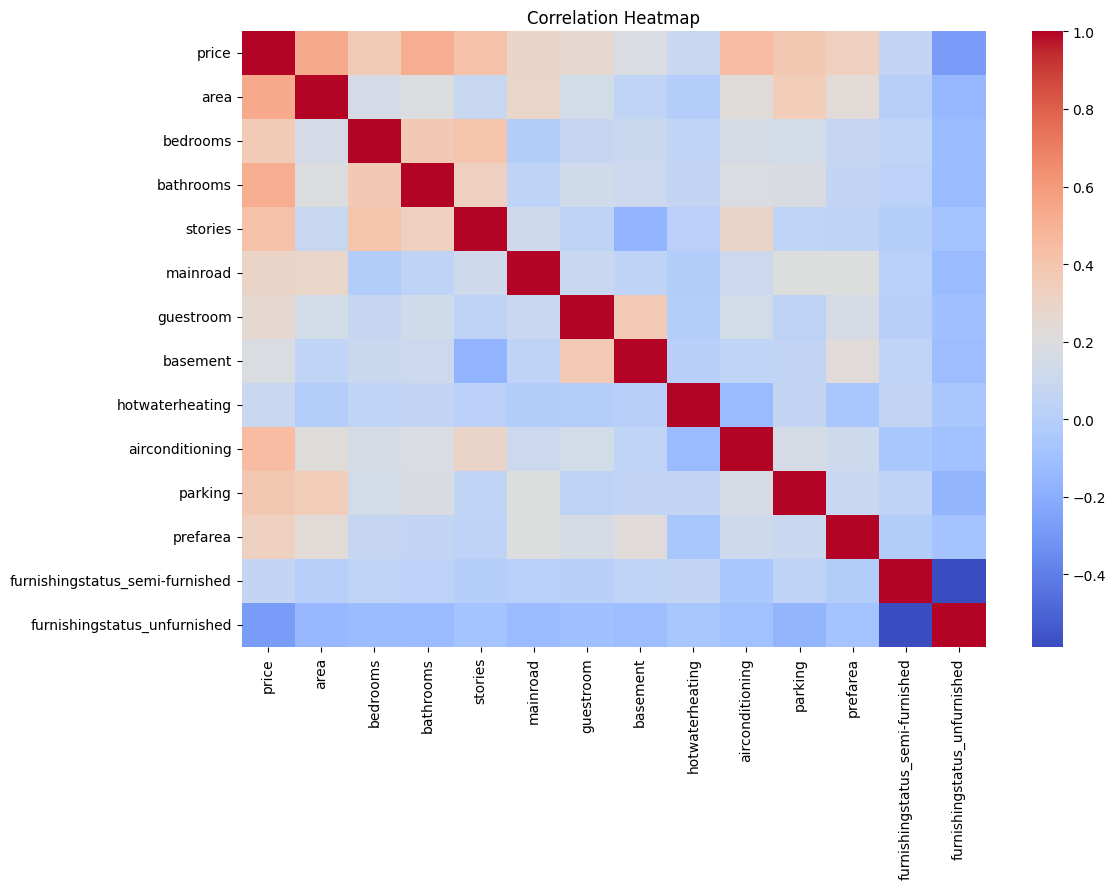

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title(
    "Correlation Heatmap"
)

plt.savefig(
    "charts/correlation_heatmap.png"
)

plt.show()

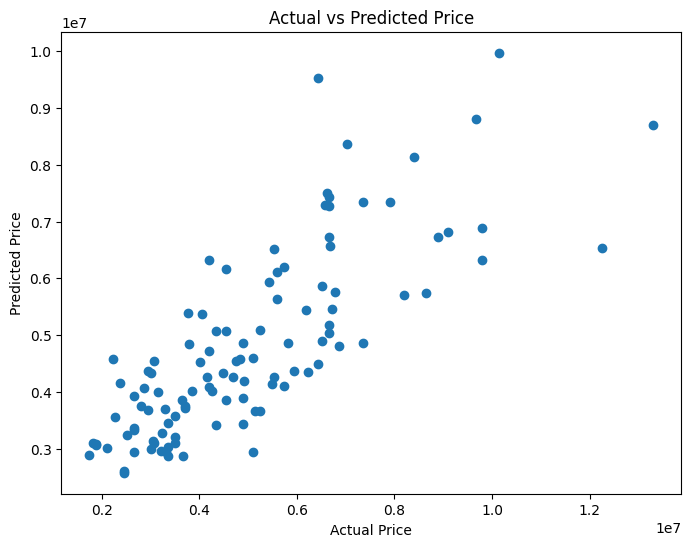

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Actual vs Predicted Price"
)

plt.savefig(
    "charts/actual_vs_predicted.png"
)

plt.show()

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance':
    rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.467917
2,bathrooms,0.151526
8,airconditioning,0.062718
9,parking,0.057820
3,stories,0.057137
1,bedrooms,0.048608
12,furnishingstatus_unfurnished,0.034998
6,basement,0.030804
10,prefarea,0.030519
7,hotwaterheating,0.017255


# Insights and Summary

### Which features influence house price the most?

The area of the house was the most influential factor affecting house prices, followed by bathrooms, air conditioning, parking availability, and number of stories.

### How accurate was the model?

The Linear Regression model achieved an R² score of approximately 0.65, meaning it explained around 65% of the variation in house prices. It performed better than the Random Forest model on this dataset.

### What surprised you in the data?

Although house area had the strongest impact on price, some houses with similar sizes showed noticeable price differences. This suggests that amenities and location-related factors also play an important role.

### Recommendation for Real Estate Businesses

Real estate companies should prioritize house area, number of bathrooms, parking facilities, and air conditioning when estimating property prices because these features have the greatest influence on market value.